<a href="https://colab.research.google.com/github/Vipinsaini15j/Anova_test_real_estate/blob/main/Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ANOVA Analysis on Real Estate Data**

##Study Objective

This project aims to analyze whether **real estate prices differ across cities** and identify the impact of various factors such as:

- City (Location)
- Property Type
- Number of Bedrooms

We use:
- **One-Way ANOVA** → Compare price across cities
- **Two-Way ANOVA** → Analyze combined effect of city and property type

---
##Key Research Questions

1. Do property prices significantly differ across cities?
2. Which factor has more influence — city or property type?
3. Do multiple variables (price + bedrooms) vary together across cities?

---

##Why This Study?

Real estate pricing depends on multiple factors. This study helps:
- Identify **price variation patterns**
- Understand **market differences across cities**
- Provide **data-driven insights for investment decisions**

##DATA LOADING

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [19]:
# load the datasets
mumbai = pd.read_csv('../data//mumbai.csv')
hyderabad = pd.read_csv('../data//hyderabad.csv')
kolkata = pd.read_csv('../data//kolkata.csv')
gurgaon = pd.read_csv('../data//gurgaon_10k.csv')


# add city column
mumbai['city'] = 'mumbia'
hyderabad['city'] = 'hyderabad'
kolkata['city'] = 'kolkata'
gurgaon['city'] = 'gurgaon'


C:\Users\Dell\AppData\Local\Temp\ipykernel_32000\205755844.py:5: DtypeWarning: Columns (66) have mixed types. Specify dtype option on import or set low_memory=False.
  gurgaon = pd.read_csv('../data//gurgaon_10k.csv')


In [20]:
print("===========mumbia==============mumbia======mumbia=========================")
print(mumbai.info())
print("===========hyderabad==============hyderabad======hyderabad=========================")
print(hyderabad.info())
print("===========kolkata==============kolkata======kolkata=========================")
print(kolkata.info())
print("===========gurgaon==============gurgaon======gurgaon=========================")
print(gurgaon.info())

===========mumbia==============mumbia======mumbia=========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9514 entries, 0 to 9513
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SPID                        9514 non-null   int64  
 1   PROP_ID                     9514 non-null   object 
 2   PREFERENCE                  9514 non-null   object 
 3   DESCRIPTION                 9514 non-null   object 
 4   PROPERTY_TYPE               9514 non-null   object 
 5   CITY                        9514 non-null   object 
 6   TRANSACT_TYPE               6867 non-null   float64
 7   OWNTYPE                     9514 non-null   int64  
 8   BEDROOM_NUM                 9453 non-null   float64
 9   PRICE_PER_UNIT_AREA         9514 non-null   float64
 10  FURNISH                     9514 non-null   int64  
 11  FACING                      9514 non-null   int64  
 12  AGE            

##**DATA CLEANING**



In [21]:
import pandas as pd

def clean_dataset(df, city_name):
    # Step 1: Standardize column names
    df.columns = [col.strip().upper() for col in df.columns]

    # Step 2: Column mapping (handles different datasets)
    column_mapping = {
        'PRICE_PER_UNIT_AREA': ['PRICE_PER_UNIT_AREA', 'PRICE', 'PRICE_PER_SQFT', 'PRICE_PER_UNIT'],
        'BEDROOM_NUM': ['BEDROOM_NUM', 'BHK', 'BEDROOMS'],
        'PROPERTY_TYPE': ['PROPERTY_TYPE', 'TYPE', 'PROPERTY']
    }

    cleaned_df = pd.DataFrame()

    for standard_col, possible_names in column_mapping.items():
        for col in possible_names:
            if col in df.columns:
                cleaned_df[standard_col] = df[col]
                break

    # Step 3: Keep only required columns
    required_cols = ['PRICE_PER_UNIT_AREA', 'BEDROOM_NUM', 'PROPERTY_TYPE']
    cleaned_df = cleaned_df[[col for col in required_cols if col in cleaned_df.columns]]

    # Step 4: Handle missing values
    cleaned_df.dropna(inplace=True)

    # Step 5: Convert data types
    cleaned_df['PRICE_PER_UNIT_AREA'] = pd.to_numeric(cleaned_df['PRICE_PER_UNIT_AREA'], errors='coerce')
    cleaned_df['BEDROOM_NUM'] = pd.to_numeric(cleaned_df['BEDROOM_NUM'], errors='coerce')

    cleaned_df.dropna(inplace=True)

    # Step 6: Add city label
    cleaned_df['CITY'] = city_name

    return cleaned_df

In [22]:
# Clean each dataset
mumbai_clean = clean_dataset(mumbai, "MUMBAI")
hyderabad_clean = clean_dataset(hyderabad, "HYDERABAD")
kolkata_clean = clean_dataset(kolkata, "KOLKATA")
gurgaon_clean = clean_dataset(gurgaon, "GURGAON")


# mumbia['city'] = 'mumbia'
# hyderabad['city'] = 'hyderabad'
# kolkata['city'] = 'kolkata'
# gurgaon['city'] = 'gurgaon'


print(mumbai_clean.head(1))
print(hyderabad_clean.head(1))
print(kolkata_clean.head(1))
print(gurgaon_clean.head(1))

   PRICE_PER_UNIT_AREA  BEDROOM_NUM PROPERTY_TYPE    CITY
0             477941.0          3.0    Farm House  MUMBAI
   PRICE_PER_UNIT_AREA  BEDROOM_NUM          PROPERTY_TYPE       CITY
0               5700.0          2.0  Residential Apartment  HYDERABAD
   PRICE_PER_UNIT_AREA  BEDROOM_NUM          PROPERTY_TYPE     CITY
0               3662.0          2.0  Residential Apartment  KOLKATA
   PRICE_PER_UNIT_AREA  BEDROOM_NUM          PROPERTY_TYPE     CITY
0               8766.0          4.0  Residential Apartment  GURGAON


##Merge all city datasets




In [23]:
# Merge all datasets
final_data = pd.concat(
    [ mumbai_clean, hyderabad_clean, kolkata_clean, gurgaon_clean],
    ignore_index=True
)

print("Final Dataset Shape:", final_data.shape)

Final Dataset Shape: (34948, 4)


In [24]:
print(final_data.head(20))
print(final_data.info())

    PRICE_PER_UNIT_AREA  BEDROOM_NUM              PROPERTY_TYPE    CITY
0              477941.0          3.0                 Farm House  MUMBAI
1                  51.0          1.0      Residential Apartment  MUMBAI
2                   6.0          4.0      Residential Apartment  MUMBAI
3                   6.0          4.0      Residential Apartment  MUMBAI
4                   7.0          3.0      Residential Apartment  MUMBAI
5                   7.0          2.0      Residential Apartment  MUMBAI
6                   2.0          4.0    Independent House/Villa  MUMBAI
7                   3.0          3.0      Residential Apartment  MUMBAI
8                  25.0          2.0      Residential Apartment  MUMBAI
9                  27.0          3.0      Residential Apartment  MUMBAI
10                 23.0          2.0      Residential Apartment  MUMBAI
11                 22.0          1.0      Residential Apartment  MUMBAI
12                 49.0          1.0           Studio Apartment 

##Exploratory Visualization

We visualize price distributions across cities using boxplots.


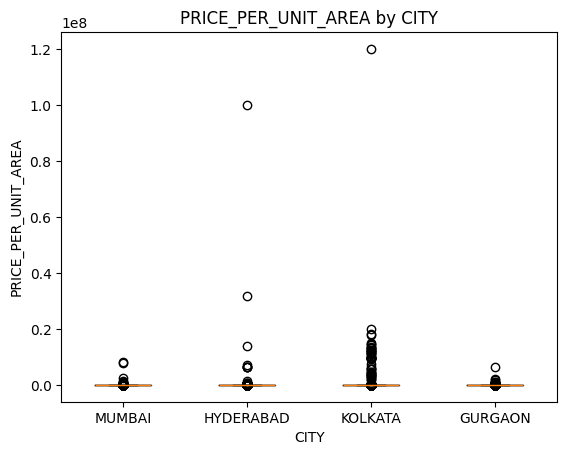

In [25]:
def boxplot(df, group, value):
    groups = df[group].unique()
    data = [df[df[group]==g][value] for g in groups]

    plt.figure()
    plt.boxplot(data)
    plt.xticks(range(1, len(groups)+1), groups)
    plt.xlabel(group)
    plt.ylabel(value)
    plt.title(f'{value} by {group}')
    plt.show()

boxplot(final_data, 'CITY', 'PRICE_PER_UNIT_AREA')

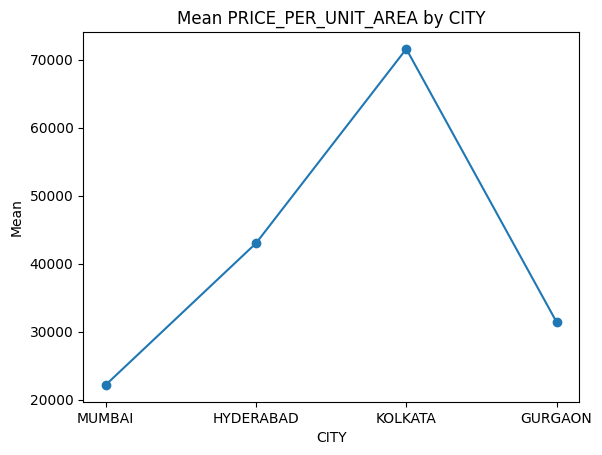

In [26]:
def mean_plot(df, group, value):
    groups = df[group].unique()
    means = [df[df[group]==g][value].mean() for g in groups]

    plt.figure()
    plt.plot(groups, means, marker='o')
    plt.xlabel(group)
    plt.ylabel('Mean')
    plt.title(f'Mean {value} by {group}')
    plt.show()

mean_plot(final_data, 'CITY', 'PRICE_PER_UNIT_AREA')

#**One-Way ANOVA on Real Estate Data**

## Objective

To test whether **property prices differ across cities**.

We analyze:

- Independent Variable → CITY (Mumbai, Hyderabad, Kolkata, Gurgaon)  
- Dependent Variable → PRICE_PER_UNIT_AREA  

---

##  Research Question

Do different cities have significantly different property prices?

In [27]:
def one_way_anova(data, group_col, value_col):
    groups = data[group_col].unique()
    grand_mean = data[value_col].mean()

    SSB, SSW = 0, 0
    N = len(data)
    k = len(groups)

    for g in groups:
        vals = data[data[group_col]==g][value_col]
        mean = vals.mean()
        n = len(vals)

        SSB += n * (mean - grand_mean)**2
        SSW += sum((vals - mean)**2)

    dfb = k - 1
    dfw = N - k

    MSB = SSB / dfb
    MSW = SSW / dfw

    F = MSB / MSW

    return F, dfb, dfw

F, d1, d2 = one_way_anova(final_data, 'CITY', 'PRICE_PER_UNIT_AREA')
print(F)

4.555126445889311


---

##Interpretation

- If F is **large** → Groups differ significantly  
- If F is **small** → Groups are similar  

In [28]:
import scipy.special # Import scipy for numerically stable beta function

def beta(a,b):
    # Use scipy's beta function to avoid OverflowError with large inputs
    return scipy.special.beta(a,b)

def f_pdf(x,d1,d2):
    return ((d1/d2)**(d1/2)*x**(d1/2-1)) / (beta(d1/2,d2/2)*(1+(d1/d2)*x)**((d1+d2)/2))

def p_value(F,d1,d2):
    step=1000
    width=F/step
    area=0
    for i in range(step):
        x=i*width
        area+=f_pdf(x,d1,d2)*width
    return 1-area

p = p_value(F,d1,d2)
print(p)

0.0035450883575436354


#Results Interpretation

- If p < 0.05 → Significant difference  
- If p ≥ 0.05 → No significant difference  

### Insight

If significant:

Property prices vary across cities .  Location plays a major role  

If not:

Prices are similar across cities  

In [29]:
if p < 0.05:
    print(" Significant difference: City affects price")
else:
    print(" No significant difference")

 Significant difference: City affects price


#**Two-Way ANOVA on Real Estate Data**

## Objective

To analyze the effect of **two factors simultaneously** on property prices:

- Factor A → CITY  
- Factor B → PROPERTY TYPE  

- Dependent Variable → PRICE_PER_UNIT_AREA  

---

## Research Questions

1. Does **city affect property price?**  
2. Does **property type affect price?**  
3. Which factor has a stronger influence?

In [30]:
def two_way_anova_full(data, factor1, factor2, value):

    grand_mean = data[value].mean()

    levels1 = data[factor1].unique()   # CITY
    levels2 = data[factor2].unique()   # PROPERTY TYPE

    SSA, SSB, SSE = 0, 0, 0

    # Factor A (City)
    for a in levels1:
        subset = data[data[factor1] == a]
        mean_a = subset[value].mean()
        SSA += len(subset) * (mean_a - grand_mean) ** 2

    # Factor B (Property Type)
    for b in levels2:
        subset = data[data[factor2] == b]
        mean_b = subset[value].mean()
        SSB += len(subset) * (mean_b - grand_mean) ** 2

    # Error (interaction + residual)
    for a in levels1:
        for b in levels2:
            subset = data[(data[factor1] == a) & (data[factor2] == b)]
            if len(subset) > 0:
                mean_ab = subset[value].mean()
                SSE += sum((subset[value] - mean_ab) ** 2)

    # Degrees of freedom
    dfA = len(levels1) - 1
    dfB = len(levels2) - 1
    dfE = len(data) - (len(levels1) * len(levels2))

    # Mean squares
    MSA = SSA / dfA
    MSB = SSB / dfB
    MSE = SSE / dfE

    # F-statistics
    FA = MSA / MSE
    FB = MSB / MSE

    return {
        "SSA": SSA,
        "SSB": SSB,
        "SSE": SSE,
        "FA": FA,
        "FB": FB,
        "dfA": dfA,
        "dfB": dfB,
        "dfE": dfE
    }

# Run Two-Way ANOVA
result_2way = two_way_anova_full(final_data, 'CITY', 'PROPERTY_TYPE', 'PRICE_PER_UNIT_AREA')

print(result_2way)

{'SSA': np.float64(12118132275273.152), 'SSB': np.float64(416744588717796.44), 'SSE': 3.0170937874288636e+16, 'FA': np.float64(4.6757319173064), 'FB': np.float64(96.47951997397749), 'dfA': 3, 'dfB': 5, 'dfE': 34924}


In [31]:
FA = result_2way["FA"]
FB = result_2way["FB"]

dfA = result_2way["dfA"]
dfB = result_2way["dfB"]
dfE = result_2way["dfE"]

pA = p_value(FA, dfA, dfE)
pB = p_value(FB, dfB, dfE)

print("City Effect p-value:", pA)
print("Property Type Effect p-value:", pB)

City Effect p-value: 0.0030189961521411846
Property Type Effect p-value: 0.0005890572709386088


# Two-Way ANOVA Results Interpretation

## 🔹 City Effect
- If p < 0.05 → City significantly affects price  

## 🔹 Property Type Effect
- If p < 0.05 → Property type significantly affects price  

---

## Insight

- If both significant → Multiple factors influence price  
- If only one significant → Dominant factor identified  
- If none → No strong effect  

This helps in **real estate decision-making**.

In [32]:
alpha = 0.05

print("\n===== FINAL TWO-WAY ANOVA DECISION =====")

if pA < alpha:
    print(" City has a significant effect on price")
else:
    print(" City has NO significant effect")

if pB < alpha:
    print(" Property Type has a significant effect on price")
else:
    print(" Property Type has NO significant effect")


===== FINAL TWO-WAY ANOVA DECISION =====
 City has a significant effect on price
 Property Type has a significant effect on price
